# Commune centroids

Load `data/processed/shapefiles/communes_2021.gpkg` (from `scripts/geospatial/commune_centroids.py`) and map geometric vs population-weighted centroids.

Maps are displayed only (not written to disk). Before committing, clear outputs so figures are not stored in git:

```bash
python scripts/geospatial/strip_notebook_outputs.py notebooks/03_communes.ipynb
```


In [1]:
from pathlib import Path
import shutil
import subprocess

import ipynbname
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib.lines import Line2D
from shapely.geometry import box

REPO_ROOT = Path(ipynbname.path()).parent.parent
DATA_ROOT = REPO_ROOT / "data"
COMMUNES_PATH = DATA_ROOT / "processed" / "shapefiles" / "communes_2021.gpkg"
POP_GRID_PATH = DATA_ROOT / "raw" / "pop" / "poland_bbox_pop_100m.parquet"


def _kpsewhich(name: str) -> str:
    if not shutil.which("kpsewhich"):
        return ""
    return subprocess.run(
        ["kpsewhich", name], capture_output=True, text=True
    ).stdout.strip()


# Matplotlib usetex always loads type1cm.sty; shim to cm-super type1ec if needed.
if not _kpsewhich("type1cm.sty"):
    shim_dir = Path.home() / "texmf" / "tex" / "latex" / "type1cm"
    shim_dir.mkdir(parents=True, exist_ok=True)
    (shim_dir / "type1cm.sty").write_text(
        "% Shim for matplotlib usetex: map type1cm -> cm-super type1ec.\n"
        "\\ProvidesPackage{type1cm}\n"
        "\\RequirePackage{type1ec}\n"
    )

# LaTeX preamble (T1 needed for Polish \k{} ogonek; siunitx optional on lean TeX Live)
_latex_preamble = r"\usepackage[T1]{fontenc}\usepackage{amsmath}\usepackage{amssymb}"
if _kpsewhich("siunitx.sty"):
    _latex_preamble += r"\usepackage{siunitx}[=v2]"

sns.set_style("whitegrid")
plt.rcParams.update({
    # 'figure.figsize': (6*2, 2*4.5),
    "font.size": 16.0,
    "font.family": "serif",
    "font.serif": "Palatino",
    "axes.titlesize": "medium",
    "figure.titlesize": "large",
    "legend.fontsize": "medium",
    # dpi for high-res output
    "figure.dpi": 100,
    "savefig.dpi": 300,
    # Tight layout by default
    "figure.autolayout": True,
    "text.usetex": True,
    "text.latex.preamble": _latex_preamble,
})

# Polish characters -> LaTeX accents (pdflatex / usetex cannot take raw Unicode here)
_PL_LATEX = {
    "ą": r"\k{a}", "ć": r"\'c", "ę": r"\k{e}", "ł": r"\l{}",
    "ń": r"\'n", "ó": r"\'o", "ś": r"\'s", "ź": r"\'z", "ż": r"\.{z}",
    "Ą": r"\k{A}", "Ć": r"\'C", "Ę": r"\k{E}", "Ł": r"\L{}",
    "Ń": r"\'N", "Ó": r"\'O", "Ś": r"\'S", "Ź": r"\'Z", "Ż": r"\.{Z}",
}


def _fix_utf8_mojibake(s: str) -> str:
    """Undo UTF-8 bytes mis-decoded as Latin-1 (common with PRG shapefiles)."""
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def latex_text(s: str) -> str:
    s = _fix_utf8_mojibake(str(s))
    for ch, rep in _PL_LATEX.items():
        s = s.replace(ch, rep)
    return s.replace("_", r"\_").replace("&", r"\&").replace("%", r"\%")


In [2]:
communes = gpd.read_file(COMMUNES_PATH, layer="communes")
commune_candidates = gpd.read_file(COMMUNES_PATH, layer="commune_candidates")

# PRG shapefile was often read without encoding="utf-8", so names are UTF-8-as-Latin-1.
communes["JPT_NAZWA_"] = communes["JPT_NAZWA_"].map(_fix_utf8_mojibake)

# GPKG stores extra point columns as WKT; parse once (idempotent if already Points).
for _col in ("centroid", "weighted_centroid"):
    if communes[_col].dtype == object:
        communes[_col] = gpd.GeoSeries.from_wkt(communes[_col], crs=communes.crs)

print(f"{len(communes)} communes  |  CRS={communes.crs}  |  pop={int(communes['pop'].sum()):,}")


print(f"{len(communes)} communes  |  CRS={communes.crs}  |  pop={int(communes['pop'].sum()):,}")

2477 communes  |  CRS=EPSG:3035  |  pop=37,017,276
2477 communes  |  CRS=EPSG:3035  |  pop=37,017,276


## 1. Subdivision into gminas

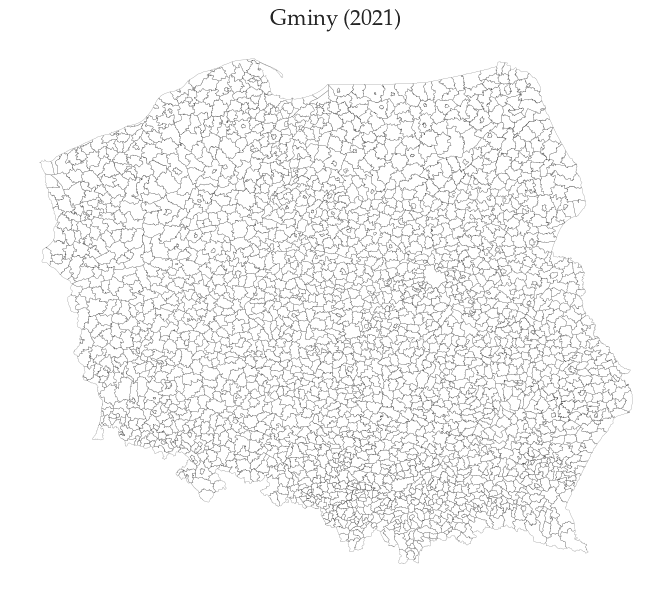

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
communes.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.35",
    linewidth=0.15,
)
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(r"Gminy (2021)")
fig.tight_layout()
plt.show()

## 2. Gminy with population-weighted centroids

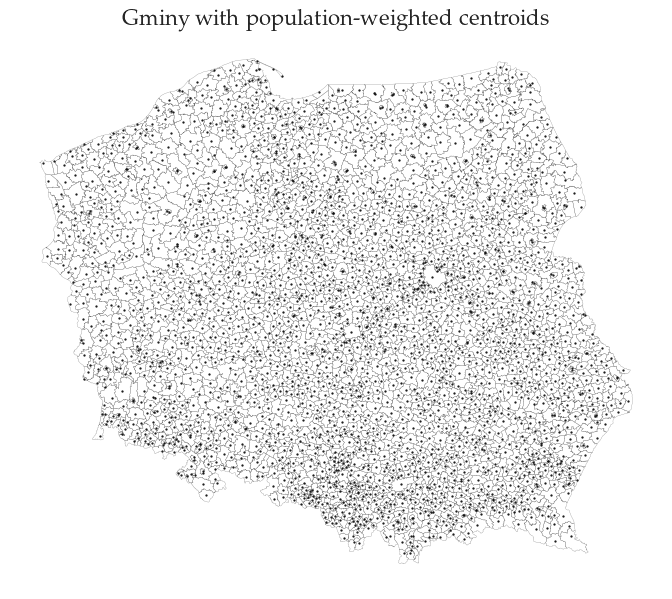

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
communes.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.35",
    linewidth=0.15,
)
gpd.GeoSeries(communes["weighted_centroid"], crs=communes.crs).plot(
    ax=ax,
    color="0.05",
    markersize=1.5,
    marker=".",
)
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(r"Gminy with population-weighted centroids")
fig.tight_layout()
plt.show()

## 3. Close-up: random gmina, population grid, and both centroids

In [ ]:
rng = np.random.default_rng()
# Prefer a commune with enough populated cells for a readable close-up
#candidates = communes.loc[communes["pop"].between(5_000, 40_000)]
candidates = communes.loc[communes["pop"] > 0]
if candidates.empty:
    candidates = communes.loc[communes["pop"] > 0]
gmina = candidates.sample(1, random_state=int(rng.integers(0, 2**31 - 1))).iloc[0]

gmina = communes.loc[communes["JPT_KOD_JE"] == "1465011"].iloc[0]

print(f"{gmina['JPT_NAZWA_']}  (TERYT {gmina['JPT_KOD_JE']})  pop={int(gmina['pop']):,}")

1539    Warszawa
Name: JPT_NAZWA_, dtype: object  (TERYT 1539    1465011
Name: JPT_KOD_JE, dtype: object)  pop=1,861,075


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_41153/2014878031.py:11: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"{gmina['JPT_NAZWA_']}  (TERYT {gmina['JPT_KOD_JE']})  pop={int(gmina['pop']):,}")


In [9]:
gmina_poly = gpd.GeoSeries([gmina.geometry], crs=communes.crs)
minx, miny, maxx, maxy = gmina_poly.total_bounds
pad = 200  # metres

# Rough lon/lat window from the projected bbox (with margin) to limit parquet rows
bbox_wgs = (
    gpd.GeoSeries([box(minx - pad, miny - pad, maxx + pad, maxy + pad)], crs=communes.crs)
    .to_crs("EPSG:4326")
    .total_bounds
)
lon_min, lat_min, lon_max, lat_max = bbox_wgs

pop = pd.read_parquet(
    POP_GRID_PATH,
    filters=[
        ("lon", ">=", float(lon_min)),
        ("lon", "<=", float(lon_max)),
        ("lat", ">=", float(lat_min)),
        ("lat", "<=", float(lat_max)),
        ("population", ">", 0),
    ],
)

pop_gdf = gpd.GeoDataFrame(
    pop,
    geometry=gpd.points_from_xy(pop["lon"], pop["lat"]),
    crs="EPSG:4326",
).to_crs(communes.crs)

# Keep cells whose centres fall inside this gmina; draw as 100 m squares
inside = pop_gdf.geometry.within(gmina.geometry)
pop_gdf = pop_gdf.loc[inside].copy()
half = 50.0  # 100 m cells in EPSG:3035
pop_gdf["geometry"] = [
    box(x - half, y - half, x + half, y + half)
    for x, y in zip(pop_gdf.geometry.x, pop_gdf.geometry.y)
]

print(f"{len(pop_gdf)} populated 100 m cells inside the gmina")


GeometryTypeError: Unknown geometry type: 'featurecollection'

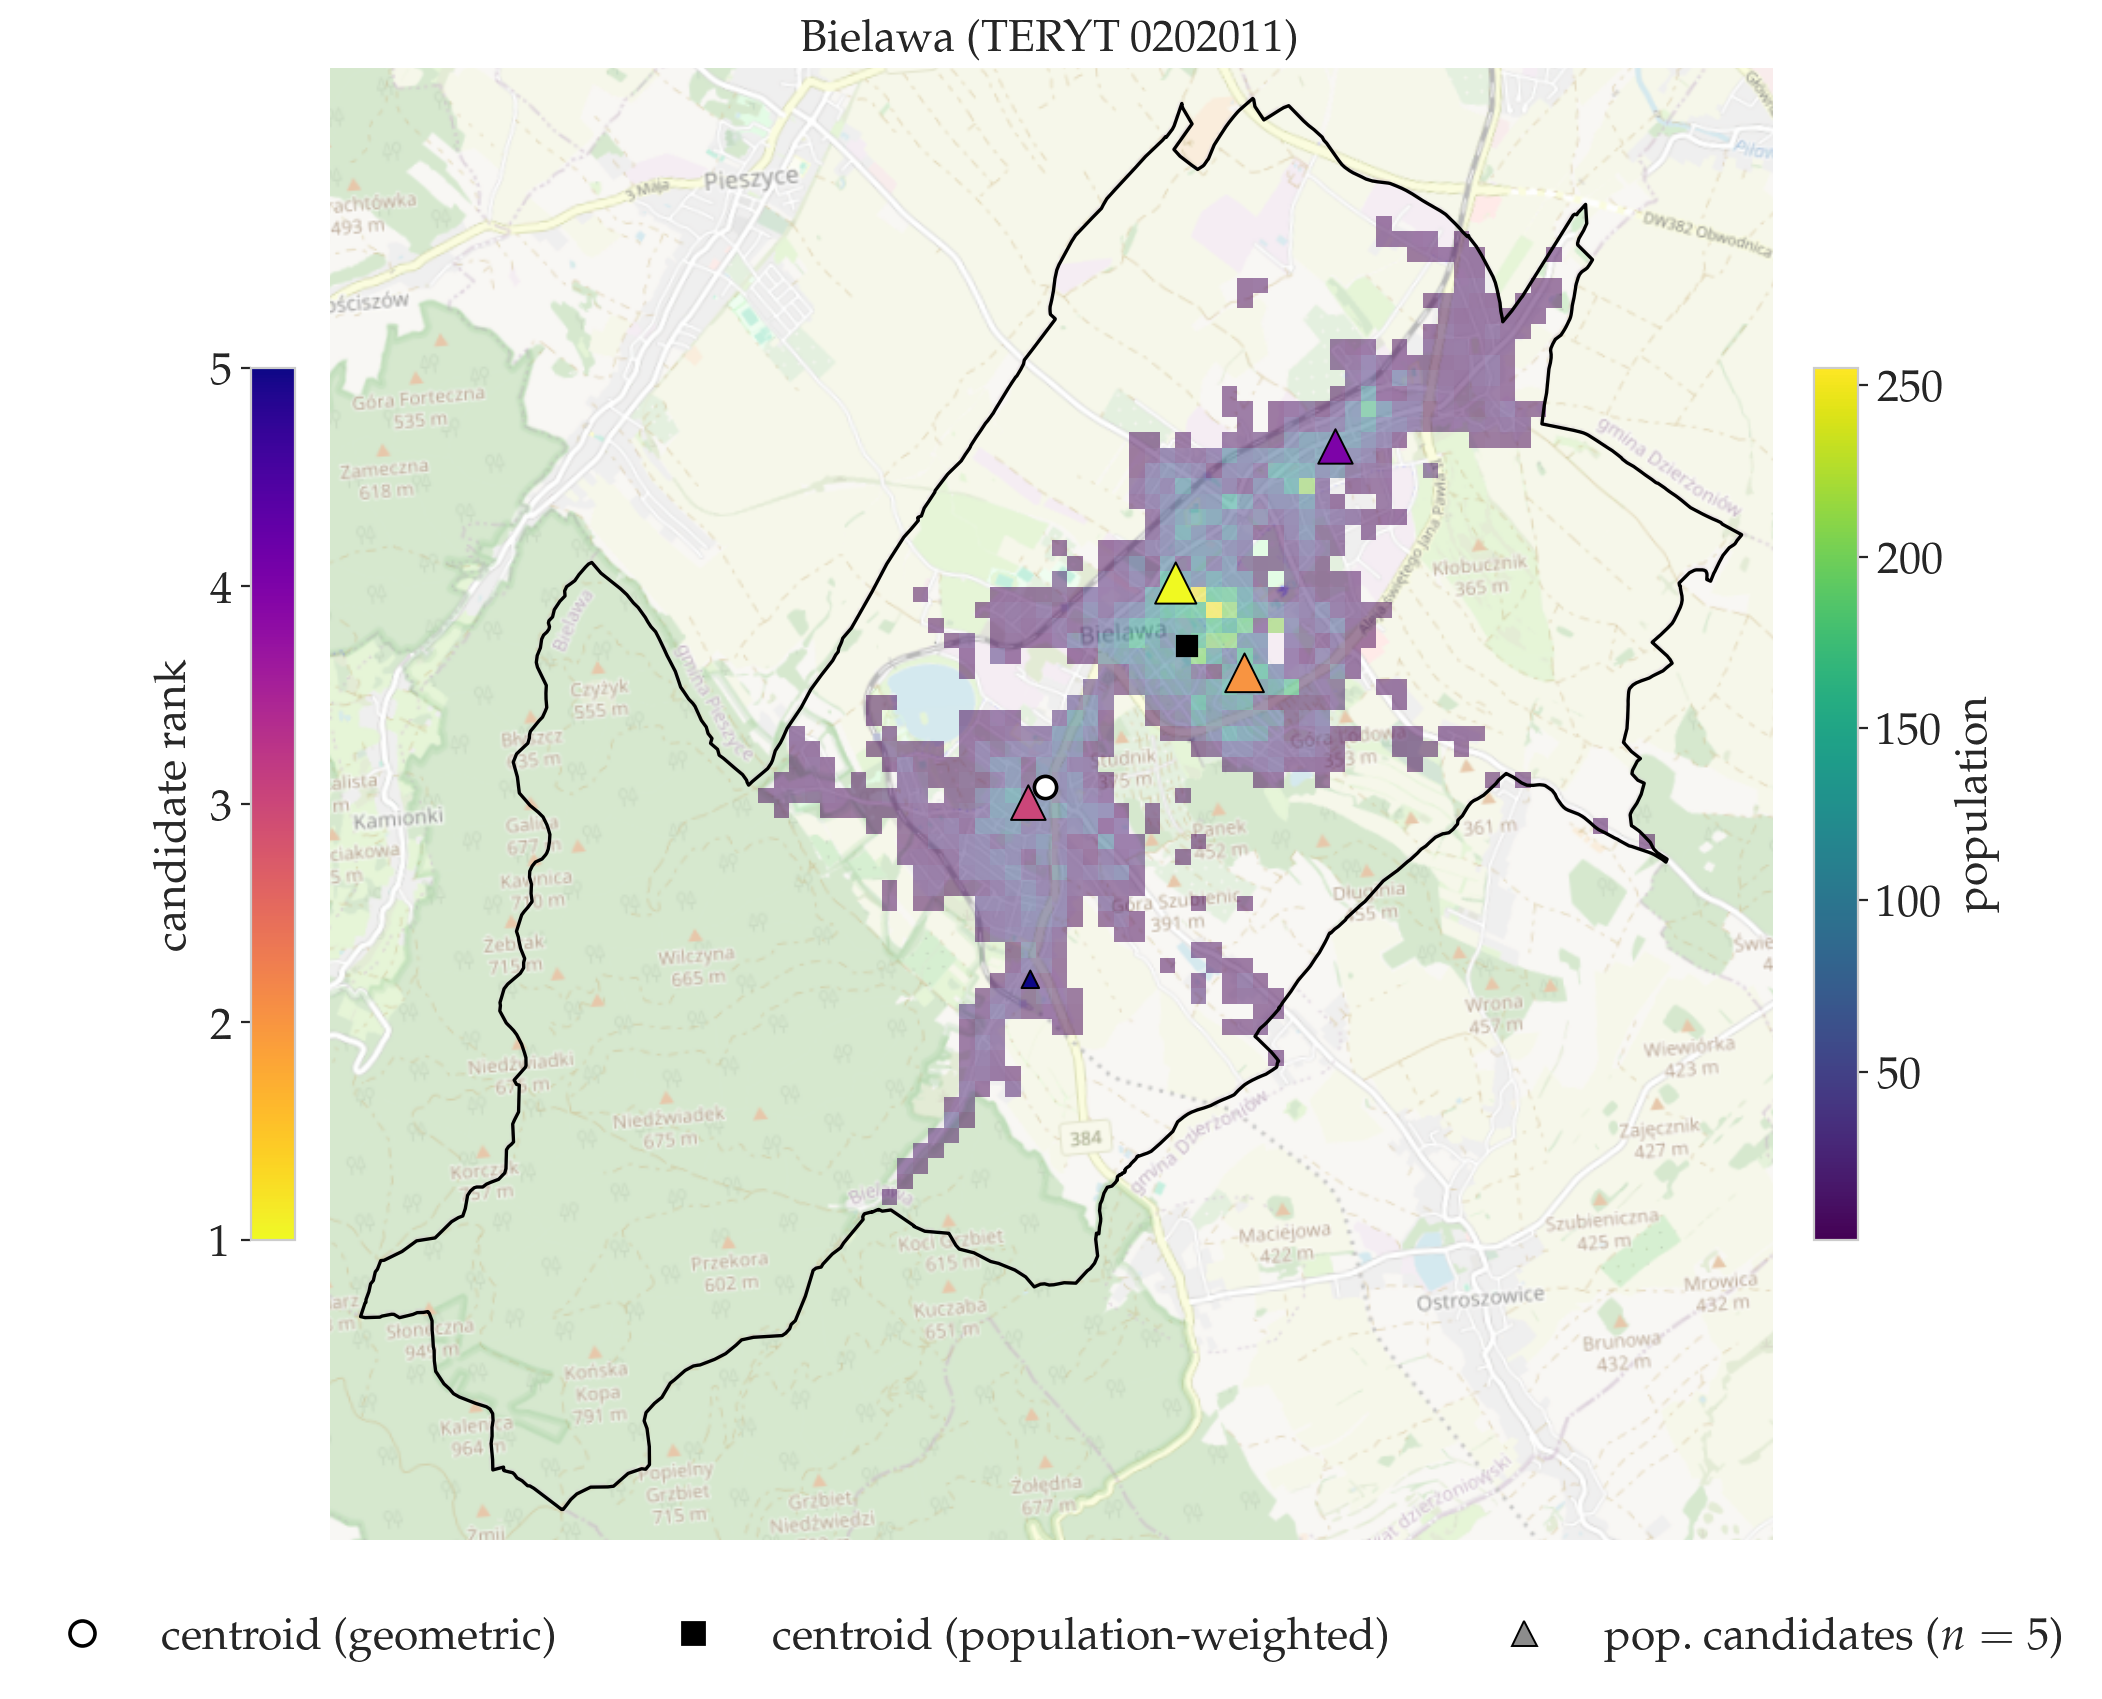

In [7]:
fig, ax = plt.subplots(figsize=(11, 9))
# Change dpi to 200
fig.set_dpi(200)

# Extent first so the basemap matches the close-up window
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

# OSM Mapnik basemap (background, low alpha). Attribution off: usetex breaks cx labels.
# OSM tile servers block contextily's default User-Agent (HTTP 403 "Access blocked");
# pass an identifying UA per https://operations.osmfoundation.org/policies/tiles/

cx.add_basemap(
    ax,
    crs=communes.crs,
    source=cx.providers.OpenStreetMap.Mapnik,
    headers={
        "user-agent": (
            "QSE-Poland-paper/1.0 "
            "(research notebook; https://github.com/jendrkk/QSE_Poland_paper)"
        )
    },
    alpha=0.5,
    zorder=0,
    attribution=False,
)

pop_gdf.plot(
    ax=ax,
    column="population",
    cmap="viridis",
    edgecolor="none",
    alpha=0.5,
    legend=True,
    legend_kwds={
        "label": r"population",
        "shrink": 0.55,
        "pad": 0.02,
    },
    zorder=2,
)
gpd.GeoSeries([gmina.geometry], crs=communes.crs).plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.0",
    linewidth=1.2,
    zorder=3,
)

c_unw = gmina["centroid"]
c_w = gmina["weighted_centroid"]
ax.plot(
    c_unw.x, c_unw.y, "o",
    color="0.0", markersize=8, markerfacecolor="white",
    markeredgewidth=1.3, zorder=5,
)
ax.plot(
    c_w.x, c_w.y, "s",
    color="0.0", markersize=7, markerfacecolor="0.0",
    markeredgewidth=0.8, zorder=5,
)

# Population-cluster candidates for this TERYT (size ~ cand_pop, colour = cand_rank)
gmina_cands = commune_candidates.loc[
    commune_candidates["JPT_KOD_JE"] == gmina["JPT_KOD_JE"]
].copy()
n_cand = len(gmina_cands)
if n_cand > 0:
    ranks = gmina_cands["cand_rank"].to_numpy()
    pops = gmina_cands["cand_pop"].to_numpy(dtype=float)
    # Marker area scaled by cluster population (sqrt so areas ~ weight)
    size_min, size_max = 40.0, 220.0
    if pops.max() > pops.min():
        sizes = size_min + (size_max - size_min) * (
            (np.sqrt(pops) - np.sqrt(pops.min()))
            / (np.sqrt(pops.max()) - np.sqrt(pops.min()))
        )
    else:
        sizes = np.full(n_cand, 0.5 * (size_min + size_max))

    rank_min, rank_max = int(ranks.min()), int(ranks.max())
    sc_cand = ax.scatter(
        gmina_cands.geometry.x,
        gmina_cands.geometry.y,
        c=ranks,
        s=sizes,
        cmap="plasma_r",
        vmin=rank_min,
        vmax=rank_max,
        marker="^",
        edgecolors="0.0",
        linewidths=0.7,
        zorder=4,
    )
    cbar_rank = fig.colorbar(
        sc_cand,
        ax=ax,
        location="left",
        shrink=0.55,
        pad=0.02,
    )
    cbar_rank.set_label(r"candidate rank")
    cbar_rank.set_ticks(list(range(rank_min, rank_max + 1)))

# Centroid legend outside the axes, centred below the plot
legend_handles = [
    Line2D(
        [0], [0], marker="o", color="none",
        markerfacecolor="white", markeredgecolor="0.0",
        markeredgewidth=1.3, markersize=9,
        label=r"centroid (geometric)",
    ),
    Line2D(
        [0], [0], marker="s", color="none",
        markerfacecolor="0.0", markeredgecolor="0.0",
        markersize=8,
        label=r"centroid (population-weighted)",
    ),
]
if n_cand > 0:
    legend_handles.append(
        Line2D(
            [0], [0], marker="^", color="none",
            markerfacecolor="0.55", markeredgecolor="0.0",
            markeredgewidth=0.7, markersize=9,
            label=rf"pop.\ candidates ($n={n_cand}$)",
        )
    )
ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=len(legend_handles),
    borderaxespad=0.0,
)

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(
    rf"{latex_text(gmina['JPT_NAZWA_'])} (TERYT {gmina['JPT_KOD_JE']})"
)
plt.show()
